# Introduction to Pandas


Pandas stands for “Python Data Analysis Library”. It offers specialized data structures for data manipulation and analysis. 

In [4]:
from google.colab import drive
drive.mount("./drive", force_remount=True)

# to be used as a prefix for all file I/O
path_prefix = "./drive/My Drive/CS210/recitation_3"

Mounted at ./drive


In [2]:
import pandas as pd  # an alias for pandas
import numpy as np
import matplotlib.pyplot as plt
from os.path import join

# displaying option
pd.set_option('max_rows', 5)

%matplotlib inline

## Dataframe

![](https://www.cdn.geeksforgeeks.org/wp-content/uploads/creating_dataframe1.png)

*Image obtained from https://www.geeksforgeeks.org/python-pandas-dataframe/*

A dataframe is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it like a spreadsheet or a SQL table. It is the most commonly used pandas object. You may creat a dataframe from:

- Dict of 1D ndarrays, lists, dicts, or Series
- 2-D numpy.ndarray
- Structured or record ndarray
- Another DataFrame



In [38]:
fname = "nba.csv"
# we use the read_csv function
# to read the dataset into a dataframe
# it returns the dataframe object
df = pd.read_csv(join(path_prefix, fname))
#df=pd.read_csv("/content/drive/My Drive/nba.csv")

In [12]:
df.head(10) # by default returns the top 5 rows of the dataframe

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
...,...,...,...,...,...,...,...,...,...
8,Terry Rozier,Boston Celtics,12.0,PG,22.0,6-2,190.0,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36.0,PG,22.0,6-4,220.0,Oklahoma State,3431040.0


In [7]:
df.head(2)  # viewing the first two rows of the dataframe

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0


In [8]:
df.tail(2)  # viewing the last two rows of the dataframe

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
456,Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0
457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.dtypes # data types of each column

Name        object
Team        object
            ...   
College     object
Salary     float64
Length: 9, dtype: object

In [10]:
df.columns # column names

Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')

In [11]:
df.index # returns the index values

RangeIndex(start=0, stop=458, step=1)

In [13]:
df.shape # number of rows and columns

(458, 9)

In [17]:
df.describe()

,Number,Age,Weight,Salary
count,457.000000,457.000000,457.000000,4.460000e+02
mean,17.678337,26.938731,221.522976,4.842684e+06
...,...,...,...,...
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [16]:
df.describe().index  # getting statistical properties of .... columns

Index(['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'], dtype='object')

In [18]:
df.info()  # a summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    object 
 1   Team      457 non-null    object 
 2   Number    457 non-null    float64
 3   Position  457 non-null    object 
 4   Age       457 non-null    float64
 5   Height    457 non-null    object 
 6   Weight    457 non-null    float64
 7   College   373 non-null    object 
 8   Salary    446 non-null    float64
dtypes: float64(4), object(5)
memory usage: 32.3+ KB


## Series

Series is a one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). The axis labels are collectively referred to as the index.

``` py
>>> s = pd.Series(data, index=index)
```

Here, data can be

- a Python dict
- an ndarray
- a scalar value



In [26]:
print(pd.Series(np.random.randn(5)))
print("------------------")
print(pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e']))

0    0.352608
1    0.092632
2   -0.943118
3    1.154446
4    1.089951
dtype: float64
------------------
a    1.283145
b    0.868058
c   -0.723503
d   -0.770233
e    0.425187
dtype: float64




In some ways, series act as numpy arrays.



In [27]:
s = pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'])
print(s[0])

print(s["a"])  # in addition, we can use index names

print(s["a":"d"])  # slicing with index labels

print(s[s > s.median()])  # conditional indexing

np.exp(s)

-1.1449377061066925
-1.1449377061066925
a   -1.144938
b   -0.030506
c   -0.314160
d   -1.101191
dtype: float64
b   -0.030506
e    0.588734
dtype: float64


a    0.318244
b    0.969955
c    0.730402
d    0.332475
e    1.801706
dtype: float64


We can also obtain the numpy array version of series.

``` py
>>> s.values
array([ 0.4691, -0.2829, -1.5091, -1.1356,  1.2121])
```

## File I/O

With pandas, we are able to read and write a variety of data formats.

- CSV
- SQL
- JSON
- Excel
- and so on

In this notebook, let's just focus on CSV files.

In [30]:
# display the documentation for read_csv function
help(pd.read_csv)

Help on function read_csv in module pandas.io.parsers.readers:

read_csv(filepath_or_buffer: 'FilePathOrBuffer', sep=<no_default>, delimiter=None, header='infer', names=<no_default>, index_col=None, usecols=None, squeeze=False, prefix=<no_default>, mangle_dupe_cols=True, dtype: 'DtypeArg | None' = None, engine=None, converters=None, true_values=None, false_values=None, skipinitialspace=False, skiprows=None, skipfooter=0, nrows=None, na_values=None, keep_default_na=True, na_filter=True, verbose=False, skip_blank_lines=True, parse_dates=False, infer_datetime_format=False, keep_date_col=False, date_parser=None, dayfirst=False, cache_dates=True, iterator=False, chunksize=None, compression='infer', thousands=None, decimal: 'str' = '.', lineterminator=None, quotechar='"', quoting=0, doublequote=True, escapechar=None, comment=None, encoding=None, encoding_errors: 'str | None' = 'strict', dialect=None, error_bad_lines=None, warn_bad_lines=None, on_bad_lines=None, delim_whitespace=False, low_me

In [32]:
fname = "nba.csv"
nba_df = pd.read_csv(join(path_prefix, fname))
nba_df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
...,...,...,...,...,...,...,...,...,...
456,Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0
457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now, we can save this dataframe with other data formats. Let's save it as a JSON file.

In [33]:
fname = "nba.json"
# to import the dataframe as a json file
# we use the to_json function
nba_df.to_json(fname)

In [35]:
# displays the content of newly created students.json
!cat nba.json

{"Name":{"0":"Avery Bradley","1":"Jae Crowder","2":"John Holland","3":"R.J. Hunter","4":"Jonas Jerebko","5":"Amir Johnson","6":"Jordan Mickey","7":"Kelly Olynyk","8":"Terry Rozier","9":"Marcus Smart","10":"Jared Sullinger","11":"Isaiah Thomas","12":"Evan Turner","13":"James Young","14":"Tyler Zeller","15":"Bojan Bogdanovic","16":"Markel Brown","17":"Wayne Ellington","18":"Rondae Hollis-Jefferson","19":"Jarrett Jack","20":"Sergey Karasev","21":"Sean Kilpatrick","22":"Shane Larkin","23":"Brook Lopez","24":"Chris McCullough","25":"Willie Reed","26":"Thomas Robinson","27":"Henry Sims","28":"Donald Sloan","29":"Thaddeus Young","30":"Arron Afflalo","31":"Lou Amundson","32":"Thanasis Antetokounmpo","33":"Carmelo Anthony","34":"Jose Calderon","35":"Cleanthony Early","36":"Langston Galloway","37":"Jerian Grant","38":"Robin Lopez","39":"Kyle O'Quinn","40":"Kristaps Porzingis","41":"Kevin Seraphin","42":"Lance Thomas","43":"Sasha Vujacic","44":"Derrick Williams","45":"Tony Wroten","46":"Elton Bra

## Selection from a DataFrame

In [39]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [40]:
df["Name"] # returns a series object

0      Avery Bradley
1        Jae Crowder
           ...      
456      Jeff Withey
457              NaN
Name: Name, Length: 458, dtype: object

In [42]:
df[["Name", "Team", "Age"]] # returns another dataframe object

,Name,Team,Age
0,Avery Bradley,Boston Celtics,25.0
1,Jae Crowder,Boston Celtics,25.0
...,...,...,...
456,Jeff Withey,Utah Jazz,26.0
457,NaN,NaN,NaN


In [50]:
df[df["Age"] > 30]  # selection by boolean arrays

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
19,Jarrett Jack,Brooklyn Nets,2.0,PG,32.0,6-3,200.0,Georgia Tech,6300000.0
31,Lou Amundson,New York Knicks,17.0,PF,33.0,6-9,220.0,UNLV,1635476.0
...,...,...,...,...,...,...,...,...,...
420,Nazr Mohammed,Oklahoma City Thunder,13.0,C,38.0,6-10,250.0,Kentucky,222888.0
434,Chris Kaman,Portland Trail Blazers,35.0,C,34.0,7-0,265.0,Central Michigan,5016000.0


### Index Mechanism

 The axis labeling information in pandas objects serves many purposes:

    - Identifies data (i.e. provides metadata) using known indicators, important for analysis, visualization, and interactive console display.
    - Enables automatic and explicit data alignment.
    - Allows intuitive getting and setting of subsets of the data set.

![](https://media.geeksforgeeks.org/wp-content/uploads/index-15.png)

By default, whenever you read a dataframe from a file, a zero-based index column is generated automatically, unless you specify your indices. 

Below, you may observe the the current dataframe contains zero-based indices, which is represented as a `RangeIndex` object.



In [51]:
# returns the index values
df.index

RangeIndex(start=0, stop=458, step=1)

In order to change the index values, you can call `set_index` method, which returns a new dataframe.

In [ ]:
# sets the Name column
# as the new index
# and returns a new dataframe
df.set_index("Name")

In [53]:
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
...,...,...,...,...,...,...,...,...,...
456,Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0
457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### An Important Note

In pandas, most of the methods return a new dataframe and do not alter the original. Which means, whenever you want to make sure that you modify the original dataframe, you mainly have two options:

- Assign the returned dataframe to the original.
  - df = df.set_index(...)  # since set_index method returns the altered df
- Set `inplace` parameter to `True`.
  - df.set_index(..., inplace=True) 

Please pay attention that, whenever you set the `inplace` parameter to `True`, the method would not return a value. Which means if you try to do something like 

`df = df.set_index(..., inplace=True)`

you will lose your dataframe.

In [56]:
df = df.set_index("Name")  # now, we modify the original df
df

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
...,...,...,...,...,...,...,...,...
Jeff Withey,Utah Jazz,24.0,C,26.0,7-0,231.0,Kansas,947276.0
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
df.head()

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [59]:
df.index  # returns the index values

Index([ 'Avery Bradley',    'Jae Crowder',   'John Holland',    'R.J. Hunter',
        'Jonas Jerebko',   'Amir Johnson',  'Jordan Mickey',   'Kelly Olynyk',
         'Terry Rozier',   'Marcus Smart',
       ...
       'Gordon Hayward',    'Rodney Hood',     'Joe Ingles',  'Chris Johnson',
           'Trey Lyles',   'Shelvin Mack',      'Raul Neto',   'Tibor Pleiss',
          'Jeff Withey',              nan],
      dtype='object', name='Name', length=458)

With the help of index mechanism, we can apply sophisticated selection statements.

### loc vs iloc
Currently, the name of the players constitute the index column of df. And it has no order. Firstly, let's sort it by lexicographical order.




In [67]:
# sorts the instances wrt index values (curently it's player Names)
# and returns a new dataframe
df = df.sort_index(ascending=True)
df

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0
...,...,...,...,...,...,...,...,...
Zaza Pachulia,Dallas Mavericks,27.0,C,32.0,6-11,275.0,NaN,5200000.0
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Selection by Index Labels

.loc[] is primarily label based, but may also be used with a boolean array.

Allowed inputs are:

    A single label, e.g. 5 or 'a', (note that 5 is interpreted as a label of the index, and never as an integer position along the index).

    A list or array of labels, e.g. ['a', 'b', 'c'].

    A slice object with labels, e.g. 'a':'f'.

    Warning

    Note that contrary to usual python slices, both the start and the stop are included

    A boolean array of the same length as the axis being sliced, e.g. [True, False, True].

    A callable function with one argument (the calling Series or DataFrame) and that returns valid output for indexing (one of the above)


In [72]:
df.loc["Kobe Bryant"]  # returns a single row as a series object

Team       Los Angeles Lakers
Number                   24.0
                  ...        
College                   NaN
Salary             25000000.0
Name: Kobe Bryant, Length: 8, dtype: object

In [73]:
df.loc["Kobe Bryant":"Kristaps Porzingis", ['Team', 'Number']]  # getting only A and B from the selection
# .loc[<selection for rows>, <selection for columns>]

,Team,Number
Name,,
Kobe Bryant,Los Angeles Lakers,24.0
Kosta Koufos,Sacramento Kings,41.0
Kris Humphries,Atlanta Hawks,43.0
Kristaps Porzingis,New York Knicks,6.0


In [75]:
df[df["Age"] > 30]

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Al Jefferson,Charlotte Hornets,25.0,C,31.0,6-10,289.0,NaN,13500000.0
...,...,...,...,...,...,...,...,...
Zach Randolph,Memphis Grizzlies,50.0,PF,34.0,6-9,260.0,Michigan State,9638555.0
Zaza Pachulia,Dallas Mavericks,27.0,C,32.0,6-11,275.0,NaN,5200000.0


In [74]:
df.loc[df["Age"] > 30]  # also accepts a boolean array

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Al Jefferson,Charlotte Hornets,25.0,C,31.0,6-10,289.0,NaN,13500000.0
...,...,...,...,...,...,...,...,...
Zach Randolph,Memphis Grizzlies,50.0,PF,34.0,6-9,260.0,Michigan State,9638555.0
Zaza Pachulia,Dallas Mavericks,27.0,C,32.0,6-11,275.0,NaN,5200000.0


#### Selection by Index Positions

`df.iloc[]` select data via the position of the passed integers. In contrast to `loc[]`, the ending values are not included.

In [77]:
df.iloc[3:5]  # index labels are not important, index 5 is not included

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Adreian Payne,Minnesota Timberwolves,33.0,PF,25.0,6-10,237.0,Michigan State,1938840.0
Al Horford,Atlanta Hawks,15.0,C,30.0,6-10,245.0,Florida,12000000.0


In [79]:
df.iloc[3:5, 1:5]  #  same for the columns, the names do not matter

,Number,Position,Age,Height
Name,,,,
Adreian Payne,33.0,PF,25.0,6-10
Al Horford,15.0,C,30.0,6-10


In [83]:
df.head()

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0
Aaron Harrison,Charlotte Hornets,9.0,SG,21.0,6-6,210.0,Kentucky,525093.0
Adreian Payne,Minnesota Timberwolves,33.0,PF,25.0,6-10,237.0,Michigan State,1938840.0
Al Horford,Atlanta Hawks,15.0,C,30.0,6-10,245.0,Florida,12000000.0


In [85]:
df.iloc[3, 2]  # getting a particular value from the data frame

'PF'

## Inserting a new column

``` py
>>> df['E'] = ['one', 'one', 'two', 'three', 'four', 'three']  # just like regular dictionaries
```

In [86]:
df.head()

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0
Aaron Harrison,Charlotte Hornets,9.0,SG,21.0,6-6,210.0,Kentucky,525093.0
Adreian Payne,Minnesota Timberwolves,33.0,PF,25.0,6-10,237.0,Michigan State,1938840.0
Al Horford,Atlanta Hawks,15.0,C,30.0,6-10,245.0,Florida,12000000.0


In [89]:
df_c.index

Index([       'Aaron Brooks',        'Aaron Gordon',      'Aaron Harrison',
             'Adreian Payne',          'Al Horford',        'Al Jefferson',
           'Al-Farouq Aminu',       'Alan Anderson',       'Alan Williams',
                'Alec Burks',
       ...
           'Wesley Matthews',         'Will Barton', 'Willie Cauley-Stein',
               'Willie Reed',     'Wilson Chandler',      'Xavier Munford',
               'Zach LaVine',       'Zach Randolph',       'Zaza Pachulia',
                         nan],
      dtype='object', name='Name', length=458)

In [100]:
df_c = df.copy()  # making a copy of the current dataframe

In [101]:
df_c = df_c.dropna()

In [102]:
df_c["Dummy"] = [np.random.choice(list(i)) for i in df_c.index]  # iterating over the index labels and extracting a random letter
df_c.head()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Team,Number,Position,Age,Height,Weight,College,Salary,Dummy
Name,,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0,A
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0,G
Aaron Harrison,Charlotte Hornets,9.0,SG,21.0,6-6,210.0,Kentucky,525093.0,r
Adreian Payne,Minnesota Timberwolves,33.0,PF,25.0,6-10,237.0,Michigan State,1938840.0,A
Al Horford,Atlanta Hawks,15.0,C,30.0,6-10,245.0,Florida,12000000.0,


In [103]:
df_c["Salary_Over_Age"] = df_c["Salary"] * df_c["Age"]  # we can also use existing columns 

df_c.head()

,Team,Number,Position,Age,Height,Weight,College,Salary,Dummy,Salary_Over_Age
Name,,,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0,A,69750000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0,G,83433600.0
Aaron Harrison,Charlotte Hornets,9.0,SG,21.0,6-6,210.0,Kentucky,525093.0,r,11026953.0
Adreian Payne,Minnesota Timberwolves,33.0,PF,25.0,6-10,237.0,Michigan State,1938840.0,A,48471000.0
Al Horford,Atlanta Hawks,15.0,C,30.0,6-10,245.0,Florida,12000000.0,,360000000.0


## Dropping Rows and Columns

We'll utilize the `.drop` method to discard values from a dataframe.

      Drop specified labels from rows or columns.
      Remove rows or columns by specifying label names and corresponding axis, or by specifying directly index or column names.

In order to drop rows from a dataframe, we may provide the **index labels** of the desired rows.

In [104]:
# drops/discards the instances
# where the index value (player name)
# is equal to the given value
# and returns the modified dataframe
df_c.drop("Al Horford")

,Team,Number,Position,Age,Height,Weight,College,Salary,Dummy,Salary_Over_Age
Name,,,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0,A,69750000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0,G,83433600.0
...,...,...,...,...,...,...,...,...,...,...
Zach LaVine,Minnesota Timberwolves,8.0,PG,21.0,6-5,189.0,UCLA,2148360.0,n,45115560.0
Zach Randolph,Memphis Grizzlies,50.0,PF,34.0,6-9,260.0,Michigan State,9638555.0,,327710870.0


In [106]:
# the same operation with multiple values
df_c.drop(["Al Horford", "Aaron Brooks"])

,Team,Number,Position,Age,Height,Weight,College,Salary,Dummy,Salary_Over_Age
Name,,,,,,,,,,
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0,G,83433600.0
Aaron Harrison,Charlotte Hornets,9.0,SG,21.0,6-6,210.0,Kentucky,525093.0,r,11026953.0
...,...,...,...,...,...,...,...,...,...,...
Zach LaVine,Minnesota Timberwolves,8.0,PG,21.0,6-5,189.0,UCLA,2148360.0,n,45115560.0
Zach Randolph,Memphis Grizzlies,50.0,PF,34.0,6-9,260.0,Michigan State,9638555.0,,327710870.0


In order to drop columns, all we have to do is to set the `axis` parameter to 1.

In [107]:
# by default the axis parameter is set to 0
# which applys the function on the vertical axis, aka index values
# by setting it to 1, the drop function is applied
# on the horizontal axis, aka columns
# again, it returns the modified version
df_c.drop(["Dummy", "Salary_Over_Age"], axis=1)

,Team,Number,Position,Age,Height,Weight,College,Salary
Name,,,,,,,,
Aaron Brooks,Chicago Bulls,0.0,PG,31.0,6-0,161.0,Oregon,2250000.0
Aaron Gordon,Orlando Magic,0.0,PF,20.0,6-9,220.0,Arizona,4171680.0
...,...,...,...,...,...,...,...,...
Zach LaVine,Minnesota Timberwolves,8.0,PG,21.0,6-5,189.0,UCLA,2148360.0
Zach Randolph,Memphis Grizzlies,50.0,PF,34.0,6-9,260.0,Michigan State,9638555.0


## Applying a Function

In [108]:
data = {
    "age": np.random.choice(np.arange(18, 23), 10, p=[0.2, 0.1, 0.2, 0.1, 0.4]),
    "gpa": np.round(np.random.uniform(0, 4, (10, )), decimals=2),
    "name": np.random.choice(["luigi", "nikola", "diana", "Cecilia"], 10)
}

df_sample = pd.DataFrame(data)
df_sample

,age,gpa,name
0,19,0.78,nikola
1,18,2.83,nikola
...,...,...,...
8,18,3.25,Cecilia
9,22,1.86,Cecilia


Let's add a new column that stores the class of each student based on their ages.

In [109]:
def assign_class(age):
    """
    age parameter will be coming from the values stored in "age" column
    """
    if age == 22:
        return "senior"
    elif age == 21:
        return "junior"
    elif age == 20:
        return "sophomore"
    else:
        return "freshman"

df_sample["class"] = df_sample["age"].apply(assign_class)  # resulting series will be stored in a new column

In [110]:
df_sample.head()

,age,gpa,name,class
0,19,0.78,nikola,freshman
1,18,2.83,nikola,freshman
2,20,3.06,diana,sophomore
3,19,2.45,Cecilia,freshman
4,20,1.14,luigi,sophomore


Now, let's find out the students who are eligible for graduation by considering the class and gpa.

In [119]:
def can_gradute(row):
    """
    a student can only graduate if gpa >= 2.0 and class == senior
    """
    cls = row["class"]
    gpa = row["gpa"]
    
    if gpa >= 2. and cls == "senior":
        return True
    else:
        return False    

df_sample["can_graduate"] = df_sample.apply(can_gradute, axis=1)  # with axis=1, we iterate over rows

In [121]:
df_sample.head()

,age,gpa,name,class,can_graduate
0,19,0.78,nikola,freshman,False
1,18,2.83,nikola,freshman,False
2,20,3.06,diana,sophomore,False
3,19,2.45,Cecilia,freshman,False
4,20,1.14,luigi,sophomore,False


## Visualization

In the previous discussions, we talked about Matplotlib library to visualize the data we have. In addition to the plotting functionalities, it provides methods to manipulate the figures as well. However, we should prepare the data beforehand so that it can be provided to Matplotlib.

In the cell below, we visualize the annual salary of the players who play for Chicago Bulls as a bar chart.

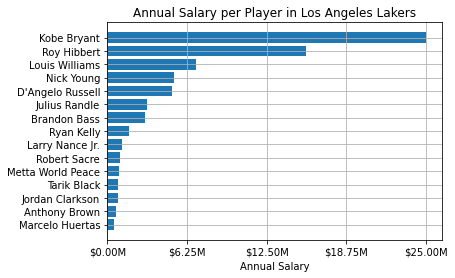

In [128]:
team = "Los Angeles Lakers"
# filter the dataframe wrt team
# and sort the instances wrt salary
# it returns a series object in which player names are indices
# and salaries are the corresponding values

salary_series = df[df["Team"] == team]["Salary"].sort_values(ascending=True)
# extract players and salaries into two different sequences
players = salary_series.index
salaries = salary_series.values

# plot the data
plt.barh(players, salaries)


# change the xticks into currency format
xlocs = np.linspace(0, max(salaries), 5)
ticks_labels = [f"${xloc/10**6:.2f}M" for xloc in xlocs]
plt.xticks(xlocs, ticks_labels)
# let's also display a grid

plt.grid()
plt.title(f"Annual Salary per Player in {team}")
plt.xlabel("Annual Salary")
plt.show()

Pandas provides a visualization module as well so that you rapidly manipulate the data and visualize it in the same expression (most of the time).

Let's generate the same figure above with Pandas.

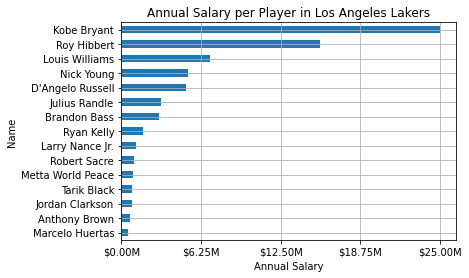

In [130]:
team = "Los Angeles Lakers"
# plot function on the returned series object
# will map the index and corresponding values
# on the x and y axes depending on the chart type
# the returned value is an Axes object
# so we can further manipulate it
ax = df[df["Team"] == team]["Salary"].sort_values(ascending=True).plot.barh(
    title=f"Annual Salary per Player in {team}",
    xticks=xlocs,
    grid=True
)

# apply the set_xticklabels function
# on the returned Axes object
ax.set_xticklabels(ticks_labels)
ax.set_xlabel("Annual Salary")
plt.show()

With Pandas, we can focus on the data manipulation and let Pandas do the work for us for visualization behind the scenes.

We can use the plot function for Dataframes and series objects, and it returns an Axes object that we can further manipulate.

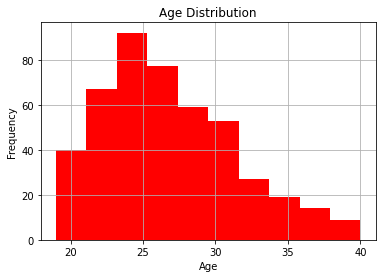

In [135]:
# histogram of the age column
# we first extract the column as a series object 
# and then call the plot.hist function
ax = df["Age"].plot.hist(grid = True, color="red")

# since it returns an Axes object
# we can change the inner elements
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
plt.show()

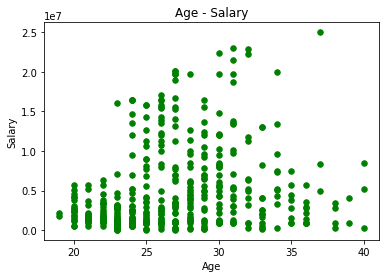

In [146]:
# depending on the chart type
# you can also specify the attributes
# to be assigned on the axes
ax = df[["Age", "Salary"]].plot.scatter(x="Age", y="Salary", s=30, color="green")  # s-> marker size
ax.set_title("Age - Salary")
plt.show()

You can create a figure and its associated axes, and then fill the position with Pandas.

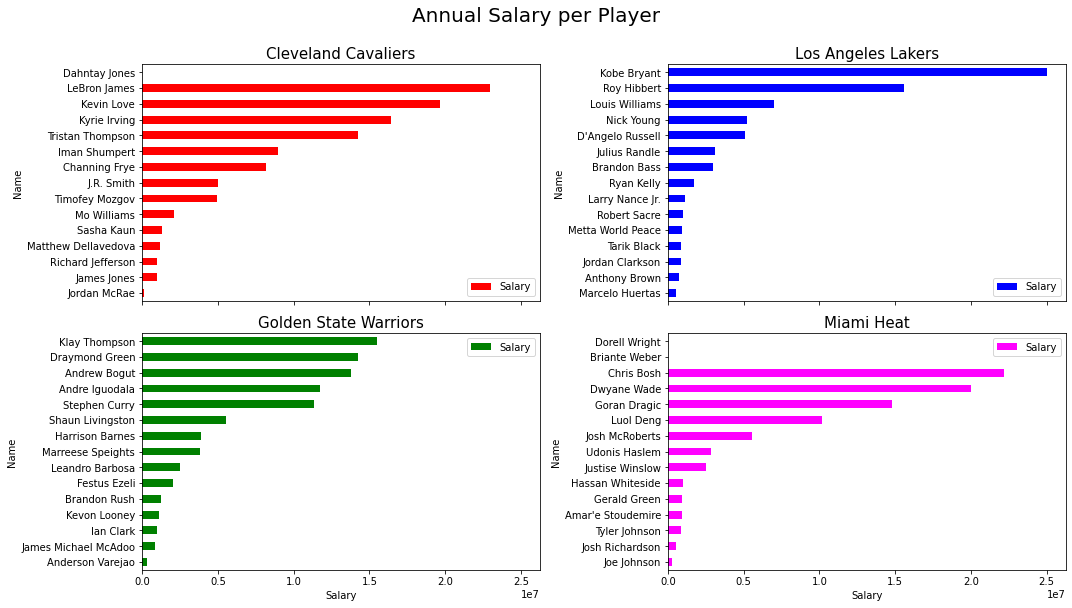

In [152]:
# 2x2 figure layout
r = 2
c = 2

# create the figure and axes
fig, axes = plt.subplots(r, c, sharex=True, figsize=(15, 8))

colors = ["red","blue","green","magenta"]

# selected teams
teams = ["Cleveland Cavaliers", "Los Angeles Lakers", "Golden State Warriors", "Miami Heat"]

for ind, team in enumerate(teams):
  # find the current axes position
  ax = axes[ind // c][ind % c]
  # display the chart in that axes
  df[df["Team"] == team]["Salary"].sort_values().plot.barh(grid=False, ax=ax, color = colors[ind])
  ax.set_title(team, fontsize=15)
  ax.set_xlabel("Salary")
  ax.legend()

# put the figure title with offset on y axis
fig.suptitle("Annual Salary per Player", y=1.05, fontsize=20)
# arrange the spacing between axes
plt.tight_layout()